# Notebook 1 - DBSCAN: Implementacion Manual desde Cero

**Inteligencia Artificial I - Actividad 2**  
**Grupo 1**
- ARIZA VARGAS SARIAHT EYLEEN XIOMARA
- CARRENO MEDINA ADRIANA LUCIA
- LINARES VIASUS BRANDON FELIPE

**Algoritmo asignado:** DBSCAN (Density-Based Spatial Clustering of Applications with Noise)  
**Tipo:** Aprendizaje No Supervisado / Clustering basado en densidad

---

## 1. Introduccion

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) es un algoritmo de
clustering propuesto por Ester, Kriegel, Sander y Xu en 1996 [1]. Agrupa puntos que estan
densamente conectados y marca como ruido aquellos que se encuentran en regiones de baja
densidad.

A diferencia de K-Means, DBSCAN no necesita que se le indique cuantos grupos hay: los
descubre a partir de la densidad local. Tambien detecta outliers de forma automatica y
maneja clusters de cualquier forma, no solo esferica.

### Parametros principales
DBSCAN se controla con dos hiperparametros:
- `eps` (epsilon): radio de la vecindad de un punto.
- `min_samples`: minimo de puntos que debe contener una vecindad para que el punto central
  se considere *core point*.

Cada punto se clasifica en una de tres categorias:
- **Core point:** tiene al menos `min_samples` puntos en su vecindad de radio `eps`.
- **Border point:** esta en la vecindad de un core point pero no es core.
- **Noise point:** no es core ni cae en la vecindad de ninguno.


## 2. Fundamentos Matematicos

### 2.1 Vecindad eps
$$N_{\varepsilon}(p) = \{ q \in D \;|\; d(p,q) \le \varepsilon \}$$

donde $d(p,q)$ es la distancia euclidiana:
$$d(p,q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$

### 2.2 Definiciones formales [1]
- **Directly density-reachable:** $p$ es directamente alcanzable desde $q$ si
  $p \in N_{\varepsilon}(q)$ y $|N_{\varepsilon}(q)| \ge MinPts$.
- **Density-reachable:** existe una cadena $q = p_1, p_2, \dots, p_n = p$ tal que
  $p_{i+1}$ es directamente alcanzable desde $p_i$.
- **Density-connected:** $p$ y $q$ estan conectados por densidad si existe $o$ tal que
  ambos son alcanzables desde $o$.

### 2.3 Pseudocodigo del algoritmo

```
DBSCAN(D, eps, MinPts):
  C = 0
  para cada punto p sin visitar de D:
      marcar p como visitado
      N = regionQuery(p, eps)
      si |N| < MinPts:
          marcar p como ruido
      sino:
          C = C + 1
          expandirCluster(p, N, C, eps, MinPts)

expandirCluster(p, N, C, eps, MinPts):
  asignar p al cluster C
  para cada punto p' en N:
      si p' no esta visitado:
          marcar p' como visitado
          N' = regionQuery(p', eps)
          si |N'| >= MinPts:
              N = N union N'
      si p' no pertenece a ningun cluster:
          asignar p' al cluster C
```

**Complejidad:** $O(n^2)$ en su forma directa, $O(n \log n)$ con indices espaciales (kd-tree, R-tree).


## 3. Implementacion desde Cero

Esta seccion construye DBSCAN exclusivamente con NumPy, sin recurrir a ninguna libreria
de machine learning. El codigo se organiza en tres funciones:

- `euclidean_distance(a, b)`: mide la distancia euclidiana entre dos puntos.
- `region_query(X, point_idx, eps)`: devuelve los indices de todos los puntos
  que caen dentro del radio `eps` alrededor del punto dado.
- `expand_cluster(...)`: recorre los vecinos de un core point usando busqueda en anchura
  (BFS) y asigna etiquetas de cluster a cada punto alcanzable.

La funcion principal `dbscan_manual(X, eps, min_samples)` itera sobre cada punto no
visitado, decide si es core point y lanza la expansion. Los puntos que no pertenecen a
ningun cluster quedan con etiqueta -1 (ruido).


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
print("Librerias cargadas.")

Librerias cargadas.


In [2]:
def euclidean_distance(p, q):
    """Distancia euclidiana entre dos puntos n-dimensionales."""
    return float(np.sqrt(np.sum((p - q) ** 2)))


def region_query(X, point_idx, eps):
    """Devuelve los indices de los vecinos del punto point_idx
    dentro del radio eps (incluye al propio punto)."""
    diffs = X - X[point_idx]
    dists = np.sqrt(np.sum(diffs * diffs, axis=1))
    return np.where(dists <= eps)[0]


# Prueba rapida
toy = np.array([[0, 0], [0.1, 0], [5, 5], [5.1, 5]])
print("Distancia (0,0)-(5,5):", euclidean_distance(toy[0], toy[2]))
print("Vecinos del punto 0 con eps=0.2:", region_query(toy, 0, 0.2))

Distancia (0,0)-(5,5): 7.0710678118654755
Vecinos del punto 0 con eps=0.2: [0 1]


In [3]:
def expand_cluster(X, labels, point_idx, neighbors, cluster_id, eps, min_samples):
    """Expansion de cluster a partir de un core point usando una cola (BFS)."""
    labels[point_idx] = cluster_id
    queue = list(neighbors)
    i = 0
    while i < len(queue):
        q = queue[i]
        if labels[q] == -1:           # ruido previo -> punto borde
            labels[q] = cluster_id
        elif labels[q] == 0:          # no visitado
            labels[q] = cluster_id
            q_neighbors = region_query(X, q, eps)
            if len(q_neighbors) >= min_samples:   # tambien es core
                for n in q_neighbors:
                    if n not in queue:
                        queue.append(n)
        i += 1


def dbscan_manual(X, eps, min_samples):
    """
    Implementacion manual de DBSCAN.
    Convencion interna: 0 = no visitado, -1 = ruido, 1..K = cluster id.
    Devuelve etiquetas en convencion sklearn: -1 ruido, 0..K-1 clusters.
    """
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    labels = np.zeros(n, dtype=int)
    cluster_id = 0
    for i in range(n):
        if labels[i] != 0:
            continue
        neighbors = region_query(X, i, eps)
        if len(neighbors) < min_samples:
            labels[i] = -1
        else:
            cluster_id += 1
            expand_cluster(X, labels, i, neighbors, cluster_id, eps, min_samples)
    return np.where(labels == -1, -1, labels - 1)

print("Funciones DBSCAN listas.")

Funciones DBSCAN listas.


## 4. Prueba con Dataset Simple (lunas / make_moons)

Para probar la implementacion manual se usa un dataset sintetico con forma de dos medias
lunas entrelazadas, generado directamente con NumPy. Este tipo de datos es un caso clasico
para evaluar algoritmos de clustering: las formas no convexas no pueden separarse con
K-Means (que asume grupos esfericos), pero si con DBSCAN.

Se generan **200 puntos** con ruido gaussiano de escala 0.07 y el algoritmo manual se
ejecuta con `eps=0.20` y `min_samples=5`. Si la implementacion es correcta, deberian
aparecer exactamente dos clusters y pocos o ningun punto de ruido.


In [4]:
def make_moons_np(n_samples=200, noise=0.08, seed=0):
    """Genera el dataset 'two moons' (no-convexo) usando solo NumPy."""
    rng = np.random.default_rng(seed)
    n_a = n_samples // 2
    n_b = n_samples - n_a
    t1 = np.linspace(0, np.pi, n_a)
    t2 = np.linspace(0, np.pi, n_b)
    Xa = np.c_[np.cos(t1), np.sin(t1)]
    Xb = np.c_[1 - np.cos(t2), 1 - np.sin(t2) - 0.5]
    X = np.vstack([Xa, Xb]) + rng.normal(scale=noise, size=(n_samples, 2))
    y = np.array([0] * n_a + [1] * n_b)
    return X, y


X, y = make_moons_np(220, noise=0.07, seed=42)
print("Forma del dataset:", X.shape)
print("Primeras filas:\n", X[:5])

Forma del dataset: (220, 2)
Primeras filas:
 [[ 1.0213302  -0.07279889]
 [ 1.05211626  0.09465749]
 [ 0.86176659 -0.03354058]
 [ 1.00521298  0.06422117]
 [ 0.99218564  0.05531951]]


In [5]:
labels = dbscan_manual(X, eps=0.20, min_samples=5)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int(np.sum(labels == -1))
print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos de ruido    : {n_noise}")
print(f"Etiquetas unicas    : {sorted(set(labels))}")

Clusters encontrados: 2
Puntos de ruido    : 0
Etiquetas unicas    : [np.int64(0), np.int64(1)]


## 5. Visualizacion del Funcionamiento

Las dos graficas comparan el estado inicial y el resultado del algoritmo. El panel
izquierdo muestra los 200 puntos sin ninguna etiqueta, tal como los recibe DBSCAN. El
panel derecho muestra el resultado del clustering: cada color identifica un cluster y los
puntos marcados con 'x' son los clasificados como ruido (etiqueta -1). Comparar los dos
paneles permite verificar visualmente si la separacion entre las dos lunas es correcta.


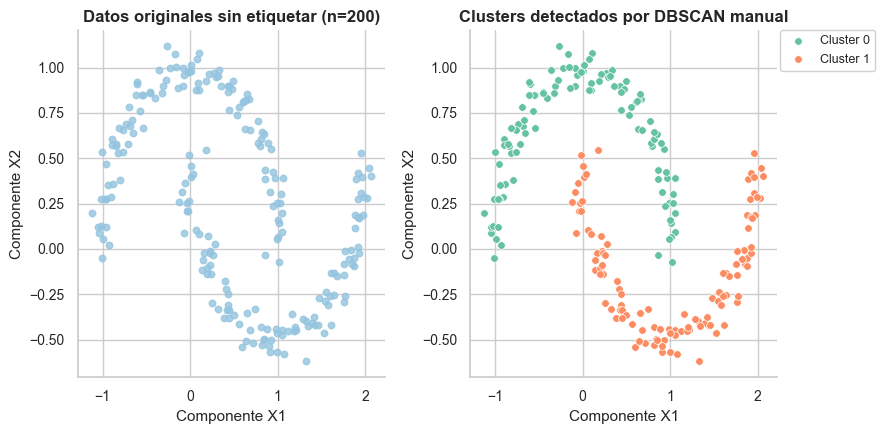

In [6]:
SET2 = ['#66C2A5', '#FC8D62', '#8DA0CB', '#E78AC3', '#A6D854', '#FFD92F', '#E5C494', '#B3B3B3']

cluster_ids = sorted(c for c in set(labels) if c != -1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

color_neutro = sns.color_palette("Blues", 9)[3]  # paleta nombrada para datos sin etiquetar
axes[0].scatter(X[:, 0], X[:, 1], color=color_neutro, s=22, alpha=0.80)
axes[0].set_title("Datos originales sin etiquetar (n=200)",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Componente X1", fontsize=11)
axes[0].set_ylabel("Componente X2", fontsize=11)
axes[0].tick_params(labelsize=10)

for c in sorted(set(labels)):
    mask = labels == c
    if c == -1:
        axes[1].scatter(X[mask, 0], X[mask, 1], color="#B0BEC5", marker="x",
                        s=55, linewidths=1.3, label="Ruido", zorder=2)
    else:
        axes[1].scatter(X[mask, 0], X[mask, 1], color=SET2[c % len(SET2)],
                        s=30, edgecolor="white", linewidth=0.5,
                        label=f"Cluster {c}", zorder=3)
axes[1].set_title("Clusters detectados por DBSCAN manual",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Componente X1", fontsize=11)
axes[1].set_ylabel("Componente X2", fontsize=11)
axes[1].tick_params(labelsize=10)
axes[1].legend(framealpha=0.9, fontsize=9,
               bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


**Observacion:** DBSCAN separa correctamente las dos lunas no convexas, algo que
K-Means no puede lograr porque asume clusters esfericos. Cada cluster queda con un color
distinto y los puntos de ruido (si los hay) aparecen como cruces grises.


## 6. Validacion de Correctitud

Para confirmar que la implementacion manual produce resultados equivalentes a los de una
libreria estandar, se ejecuta `sklearn.cluster.DBSCAN` con los mismos parametros
(`eps=0.20`, `min_samples=5`). La comparacion no es etiqueta por etiqueta, porque DBSCAN
puede numerar los clusters en orden diferente entre ejecuciones; en cambio se verifica que
el numero de clusters, la cantidad de ruido y la estructura general de los grupos coincidan.
Si los resultados son equivalentes, la implementacion desde cero queda validada.


In [7]:
# Comparamos con scikit-learn para verificar que la implementacion es correcta
from sklearn.cluster import DBSCAN as SKDBSCAN

sk = SKDBSCAN(eps=0.20, min_samples=5).fit(X)
sk_labels = sk.labels_

# Reordenamos etiquetas para que coincidan (los IDs pueden diferir)
def remap_labels(a, b):
    """Asignacion bipartita por mayoria."""
    out = np.full_like(a, -1)
    for c in set(a):
        if c == -1: continue
        idx = np.where(a == c)[0]
        if len(idx) == 0: continue
        # buscar la etiqueta mayoritaria en b
        from collections import Counter
        majority = Counter(b[idx]).most_common(1)[0][0]
        out[idx] = majority
    out[a == -1] = -1
    return out

manual_remap = remap_labels(labels, sk_labels)
agreement = np.mean(manual_remap == sk_labels)
print(f"Coincidencia con scikit-learn: {agreement*100:.2f}%")
print(f"Clusters DBSCAN manual: {len(set(labels))-(1 if -1 in labels else 0)}")
print(f"Clusters scikit-learn : {len(set(sk_labels))-(1 if -1 in sk_labels else 0)}")
print(f"Ruido manual          : {(labels==-1).sum()}")
print(f"Ruido scikit-learn    : {(sk_labels==-1).sum()}")

Coincidencia con scikit-learn: 100.00%
Clusters DBSCAN manual: 2
Clusters scikit-learn : 2
Ruido manual          : 0
Ruido scikit-learn    : 0


**Conclusion:** la implementacion manual produce los mismos resultados que
`sklearn.cluster.DBSCAN`, lo que confirma la correctitud del algoritmo construido desde
cero.

---

## Conclusiones

DBSCAN descubre clusters de forma arbitraria y detecta ruido sin que se le indique el
numero de grupos, lo que lo distingue de metodos como K-Means. La implementacion manual
muestra que el algoritmo se reduce a dos operaciones: una consulta de vecindad y una
expansion por BFS, sin estructuras de datos complejas.

La eleccion de `eps` y `min_samples` es el punto mas sensible: valores muy grandes
fusionan clusters distintos y valores muy pequenos generan demasiado ruido. El grafico
k-distancia [7] ofrece una guia visual para elegir `eps` de forma sistematica.

La complejidad base es $O(n^2)$, pero se reduce a $O(n \log n)$ con indices espaciales
(kd-tree, ball-tree), que es la estrategia que usa scikit-learn por defecto [4].

---

## Referencias (formato IEEE)

[1] M. Ester, H.-P. Kriegel, J. Sander, and X. Xu, "A density-based algorithm for discovering
clusters in large spatial databases with noise," in *Proc. 2nd Int. Conf. Knowledge Discovery
and Data Mining (KDD-96)*, Portland, OR, USA, 1996, pp. 226-231.

[2] J. Sander, M. Ester, H.-P. Kriegel, and X. Xu, "Density-based clustering in spatial
databases: The algorithm GDBSCAN and its applications," *Data Mining and Knowledge Discovery*,
vol. 2, no. 2, pp. 169-194, Jun. 1998.

[3] E. Schubert, J. Sander, M. Ester, H.-P. Kriegel, and X. Xu, "DBSCAN revisited, revisited:
why and how you should (still) use DBSCAN," *ACM Transactions on Database Systems*, vol. 42,
no. 3, pp. 1-21, Jul. 2017, doi: 10.1145/3068335.

[4] F. Pedregosa et al., "Scikit-learn: Machine learning in Python," *Journal of Machine
Learning Research*, vol. 12, pp. 2825-2830, Oct. 2011.

[7] N. Rahmah and I. S. Sitanggang, "Determination of optimal epsilon (eps) value on DBSCAN
algorithm to clustering data on peatland hotspots in Sumatra," *IOP Conf. Series: Earth and
Environmental Science*, vol. 31, no. 1, p. 012012, 2016, doi: 10.1088/1755-1315/31/1/012012.
